In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

sys.path.append(str(PROJECT_ROOT))

from src.config import (
    DATA_DIR,
    PROCESSED_DIR,
    FIX_DATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    TABLE_DIR,
)

STAGE1_DIR = PROCESSED_DIR / "stage1"
STAGE2_DIR = PROCESSED_DIR / "stage2"
STAGE2_FIGURE_DIR = FIGURE_DIR / "stage2"
STAGE2_TABLE_DIR = TABLE_DIR / "stage2"

STAGE2_DIR.mkdir(parents=True, exist_ok=True)
STAGE2_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
STAGE2_TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Stage 1 dir:", STAGE1_DIR)
print("Stage 2 dir:", STAGE2_DIR)
print("Figure dir:", STAGE2_FIGURE_DIR)

Project root: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics
Stage 1 dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage1
Stage 2 dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage2
Figure dir: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2


In [2]:
fixed_registry_path = STAGE1_DIR / "fixed_file_registry.csv"

if not fixed_registry_path.exists():
    raise FileNotFoundError(
        f"Could not find {fixed_registry_path}. "
        "Run Stage 1 first."
    )

fixed_registry = pd.read_csv(fixed_registry_path)

print("Fixed registry shape:", fixed_registry.shape)
display(fixed_registry.head())

print("\nData kind counts:")
display(fixed_registry["data_kind"].value_counts())

Fixed registry shape: (76, 19)


,original_file,original_path,relative_path,folder,stack,data_kind,time_h,part,current_A,eis_stage,fix_success,fixed_path,repair_status,repair_mode_counts,n_clean_rows,n_failed_rows,n_header_rows,n_empty_rows,validation_reason
0,FC1_Ageing_part1.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,FC1,ageing,NaN,1.0,NaN,NaN,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 65535},65535,0,1,0,ok
1,FC1_Ageing_part2.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,FC1,ageing,NaN,2.0,NaN,NaN,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 65535},65535,0,1,0,ok
2,FC1_Ageing_part3.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_Ageing_...,FC1_Without_Ripples_Excel,FC1,ageing,NaN,3.0,NaN,NaN,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 12792},12792,0,1,0,ok
3,FC1_EIS20A_postpola_T000.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS20A_...,FC1_Without_Ripples_Excel,FC1,eis,0.0,NaN,20.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok
4,FC1_EIS45A_postpola_T000.xlsx,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,data\raw\FC1_Without_Ripples_Excel\FC1_EIS45A_...,FC1_Without_Ripples_Excel,FC1,eis,0.0,NaN,45.0,postpola,True,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,{'normal_columns': 78},78,0,1,0,ok



Data kind counts:


data_kind
eis             55
polarization    16
ageing           5
Name: count, dtype: int64

In [3]:
ageing_registry = fixed_registry[
    fixed_registry["data_kind"] == "ageing"
].copy()

ageing_registry = ageing_registry.sort_values(
    by=["stack", "part", "original_file"]
).reset_index(drop=True)

print("Ageing files:", len(ageing_registry))

display(
    ageing_registry[
        [
            "original_file",
            "stack",
            "part",
            "fixed_path",
            "repair_status",
            "n_clean_rows",
            "n_failed_rows",
        ]
    ]
)

Ageing files: 5


,original_file,stack,part,fixed_path,repair_status,n_clean_rows,n_failed_rows
0,FC1_Ageing_part1.xlsx,FC1,1.0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,65535,0
1,FC1_Ageing_part2.xlsx,FC1,2.0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,65535,0
2,FC1_Ageing_part3.xlsx,FC1,3.0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,12792,0
3,FC2_Ageing_part1.xlsx,FC2,1.0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,normal,65535,0
4,FC2_Ageing_part2.csv,FC2,2.0,C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prog...,repaired,61835,0


In [4]:
def existing_cols(df, cols):
    return [col for col in cols if col in df.columns]


def save_figure(name):
    out_path = STAGE2_FIGURE_DIR / name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print("Saved:", out_path)


def basic_dataframe_info(df, name):
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    print("Columns:")
    print(list(df.columns))
    print("\nHead:")
    display(df.head())
    print("\nDescribe:")
    display(df.describe().T)

In [5]:
def estimate_median_dt(time_values):
    dt = pd.Series(time_values).diff().dropna()
    dt = dt[dt > 0]
    
    if len(dt) == 0:
        return 0.0
    
    return float(dt.median())


def make_time_continuous_by_part(df):
    """
    Makes Time_h continuous if each ageing part restarts from zero.
    If the time is already continuous, it keeps it.
    """
    df = df.copy()
    
    if "part" not in df.columns:
        df = df.sort_values("Time_h").reset_index(drop=True)
        return df
    
    df["Time_h_original"] = df["Time_h"]
    
    adjusted_parts = []
    last_end = None
    
    for part in sorted(df["part"].dropna().unique()):
        sub = df[df["part"] == part].copy()
        sub = sub.sort_values("Time_h_original")
        
        median_dt = estimate_median_dt(sub["Time_h_original"])
        
        if last_end is None:
            sub["Time_h"] = sub["Time_h_original"]
        else:
            part_min = sub["Time_h_original"].min()
            
            # If this part restarts or overlaps, shift it after previous part
            if part_min <= last_end:
                local_time = sub["Time_h_original"] - part_min
                sub["Time_h"] = local_time + last_end + median_dt
            else:
                sub["Time_h"] = sub["Time_h_original"]
        
        last_end = sub["Time_h"].max()
        adjusted_parts.append(sub)
    
    out = pd.concat(adjusted_parts, ignore_index=True)
    out = out.sort_values("Time_h").reset_index(drop=True)
    
    return out


def load_ageing_stack(ageing_registry, stack):
    """
    Load all fixed ageing files for one stack.
    """
    sub = ageing_registry[
        ageing_registry["stack"] == stack
    ].copy()
    
    if sub.empty:
        print(f"No ageing files found for {stack}")
        return None
    
    sub = sub.sort_values(["part", "original_file"])
    
    dfs = []
    
    for _, row in sub.iterrows():
        df = pd.read_csv(row["fixed_path"])
        df["stack"] = row["stack"]
        df["source_file"] = row["original_file"]
        df["part"] = row["part"]
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    
    if "Time_h" not in combined.columns:
        raise ValueError("Time_h column missing. Check Stage 1 fixing.")
    
    combined["Time_h"] = pd.to_numeric(combined["Time_h"], errors="coerce")
    combined = combined.dropna(subset=["Time_h"]).copy()
    
    combined = make_time_continuous_by_part(combined)
    
    return combined


ageing_data = {}

for stack in sorted(ageing_registry["stack"].dropna().unique()):
    df_stack = load_ageing_stack(ageing_registry, stack)
    
    if df_stack is not None:
        ageing_data[stack] = df_stack
        print(stack, df_stack.shape)
        display(df_stack.head())

FC1 (143862, 30)


,Time_raw,U1_V,U2_V,U3_V,U4_V,U5_V,Utot_V,J_A_cm2,I_A,TinH2_C,ToutH2_C,TinAIR_C,ToutAIR_C,TinWAT_C,ToutWAT_C,PinAIR_mbara,PoutAIR_mbara,PoutH2_mbara,PinH2_mbara,DinH2_l_min,DoutH2_l_min,DinAIR_l_min,DoutAIR_l_min,DWAT_l_min,HrAIRFC_percent,Time_h,stack,source_file,part,Time_h_original
0,0.000000,0.670,0.663,0.664,0.662,0.658,3.317,0.70164,70.164,25.930,38.889,41.918,51.503,53.806,55.502,1302.204,1269.602,1305.319,1292.489,4.799,2.115,23.038,21.331,2.020,48.904,0.000000,FC1,FC1_Ageing_part1.xlsx,1.0,0.000000
1,0.000156,0.670,0.663,0.663,0.662,0.659,3.317,0.70164,70.164,25.945,38.912,41.914,51.491,53.823,55.502,1301.863,1269.829,1305.205,1292.432,4.799,2.115,23.036,21.331,2.019,48.901,0.000156,FC1,FC1_Ageing_part1.xlsx,1.0,0.000156
2,0.000321,0.670,0.663,0.663,0.662,0.658,3.316,0.70168,70.168,25.943,38.895,41.912,51.512,53.803,55.496,1302.261,1269.773,1305.547,1293.059,4.801,2.115,23.038,21.331,2.016,48.913,0.000321,FC1,FC1_Ageing_part1.xlsx,1.0,0.000321
3,0.000475,0.669,0.663,0.663,0.662,0.659,3.316,0.70164,70.164,25.945,38.907,41.912,51.503,53.815,55.505,1301.863,1269.886,1305.775,1292.945,4.797,2.114,23.036,21.350,2.016,48.894,0.000475,FC1,FC1_Ageing_part1.xlsx,1.0,0.000475
4,0.000624,0.669,0.663,0.663,0.662,0.659,3.316,0.70159,70.159,25.939,38.915,41.909,51.515,53.814,55.484,1302.034,1269.659,1305.661,1293.002,4.797,2.116,23.036,21.331,2.017,48.939,0.000624,FC1,FC1_Ageing_part1.xlsx,1.0,0.000624


FC2 (127370, 30)


,Time_raw,U1_V,U2_V,U3_V,U4_V,U5_V,Utot_V,J_A_cm2,I_A,TinH2_C,ToutH2_C,TinAIR_C,ToutAIR_C,TinWAT_C,ToutWAT_C,PinAIR_mbara,PoutAIR_mbara,PoutH2_mbara,PinH2_mbara,DinH2_l_min,DoutH2_l_min,DinAIR_l_min,DoutAIR_l_min,DWAT_l_min,HrAIRFC_percent,Time_h,stack,source_file,part,Time_h_original
0,0.000000,0.669,0.665,0.664,0.666,0.661,3.325,0.69978,69.978,24.537,36.712,43.217,49.698,52.727,54.481,1299.531,1263.399,1296.308,1282.863,4.793,2.128,23.038,21.329,2.014,54.351,0.000000,FC2,FC2_Ageing_part1.xlsx,1.0,0.000000
1,0.008389,0.669,0.665,0.663,0.666,0.661,3.324,0.69973,69.973,24.552,36.603,43.197,50.200,53.189,54.916,1299.303,1263.114,1295.453,1281.952,4.805,2.126,23.036,21.327,2.020,53.213,0.008389,FC2,FC2_Ageing_part1.xlsx,1.0,0.008389
2,0.016778,0.669,0.666,0.664,0.667,0.662,3.328,0.69968,69.968,24.547,36.460,43.151,50.601,53.554,55.222,1301.010,1264.878,1295.111,1281.382,4.795,2.110,23.038,21.329,2.016,52.454,0.016778,FC2,FC2_Ageing_part1.xlsx,1.0,0.016778
3,0.025169,0.670,0.667,0.665,0.666,0.662,3.330,0.69963,69.963,24.549,36.395,43.116,50.965,53.826,55.455,1299.303,1263.399,1295.453,1281.154,4.795,2.126,23.036,21.329,2.008,51.758,0.025169,FC2,FC2_Ageing_part1.xlsx,1.0,0.025169
4,0.033559,0.672,0.667,0.664,0.666,0.662,3.331,0.69973,69.973,24.549,36.324,43.096,51.245,53.659,55.548,1299.701,1264.537,1295.453,1281.154,4.793,2.129,23.039,21.331,2.004,51.613,0.033559,FC2,FC2_Ageing_part1.xlsx,1.0,0.033559


In [6]:
combined_paths = {}

for stack, df in ageing_data.items():
    out_path = STAGE2_DIR / f"{stack}_ageing_combined.csv"
    df.to_csv(out_path, index=False)
    combined_paths[stack] = str(out_path)
    print("Saved:", out_path)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage2\FC1_ageing_combined.csv
Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage2\FC2_ageing_combined.csv


In [7]:
def ageing_quality_summary(df, stack):
    time = df["Time_h"]
    
    summary = {
        "stack": stack,
        "n_rows": len(df),
        "n_columns": df.shape[1],
        "time_min_h": time.min(),
        "time_max_h": time.max(),
        "duration_h": time.max() - time.min(),
        "duplicate_time_rows": int(time.duplicated().sum()),
        "missing_total_values": int(df.isna().sum().sum()),
    }
    
    if len(time) > 1:
        dt = time.diff().dropna()
        dt = dt[dt > 0]
        
        summary["median_dt_h"] = dt.median() if len(dt) > 0 else np.nan
        summary["max_dt_h"] = dt.max() if len(dt) > 0 else np.nan
    else:
        summary["median_dt_h"] = np.nan
        summary["max_dt_h"] = np.nan
    
    return summary


quality_summaries = []

for stack, df in ageing_data.items():
    quality_summaries.append(ageing_quality_summary(df, stack))

ageing_quality_df = pd.DataFrame(quality_summaries)

display(ageing_quality_df)

quality_path = STAGE2_TABLE_DIR / "ageing_quality_summary.csv"
ageing_quality_df.to_csv(quality_path, index=False)

print("Saved:", quality_path)

,stack,n_rows,n_columns,time_min_h,time_max_h,duration_h,duplicate_time_rows,missing_total_values,median_dt_h,max_dt_h
0,FC1,143862,30,0.0,1154.213356,1154.213356,14,0,0.00839,0.009183
1,FC2,127370,30,0.0,1020.544696,1020.544696,19,0,0.00839,0.010001


Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\tables\stage2\ageing_quality_summary.csv


In [8]:
def plot_missing_values(df, stack):
    missing_pct = df.isna().mean().sort_values(ascending=False) * 100
    
    missing_pct = missing_pct[missing_pct > 0]
    
    if len(missing_pct) == 0:
        print(f"{stack}: No missing values.")
        return
    
    plt.figure(figsize=(12, 4))
    missing_pct.plot(kind="bar")
    plt.xlabel("Column")
    plt.ylabel("Missing values (%)")
    plt.title(f"{stack}: Missing Values by Column")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    save_figure(f"{stack}_missing_values.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_missing_values(df, stack)

FC1: No missing values.
FC2: No missing values.



FC1 time gap summary:


count    143847.000000
mean          0.008024
std           0.001677
min           0.000148
25%           0.008389
50%           0.008390
75%           0.008391
max           0.009183
Name: Time_h, dtype: float64

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_time_gap_distribution.png


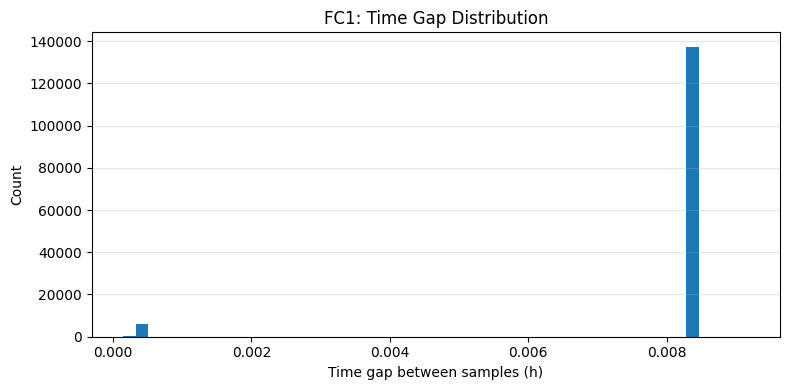


FC2 time gap summary:


count    127350.000000
mean          0.008014
std           0.001441
min           0.000049
25%           0.008389
50%           0.008390
75%           0.008391
max           0.010001
Name: Time_h, dtype: float64

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_time_gap_distribution.png


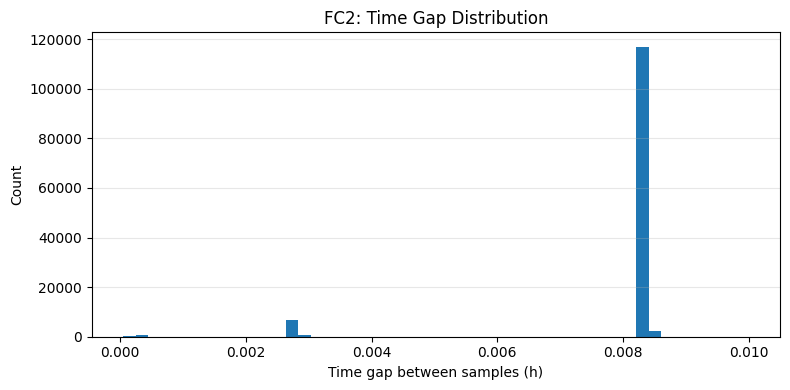

In [9]:
def plot_time_gaps(df, stack):
    dt = df["Time_h"].diff().dropna()
    dt = dt[dt > 0]
    
    if len(dt) == 0:
        print(f"{stack}: No positive time gaps found.")
        return
    
    print(f"\n{stack} time gap summary:")
    display(dt.describe())
    
    plt.figure(figsize=(8, 4))
    plt.hist(dt, bins=50)
    plt.xlabel("Time gap between samples (h)")
    plt.ylabel("Count")
    plt.title(f"{stack}: Time Gap Distribution")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    
    save_figure(f"{stack}_time_gap_distribution.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_time_gaps(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_stack_voltage_over_time.png


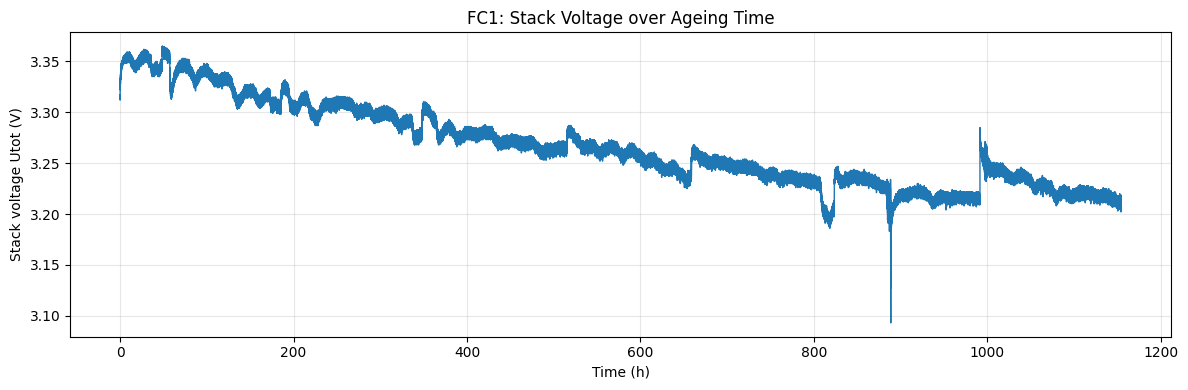

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_stack_voltage_over_time.png


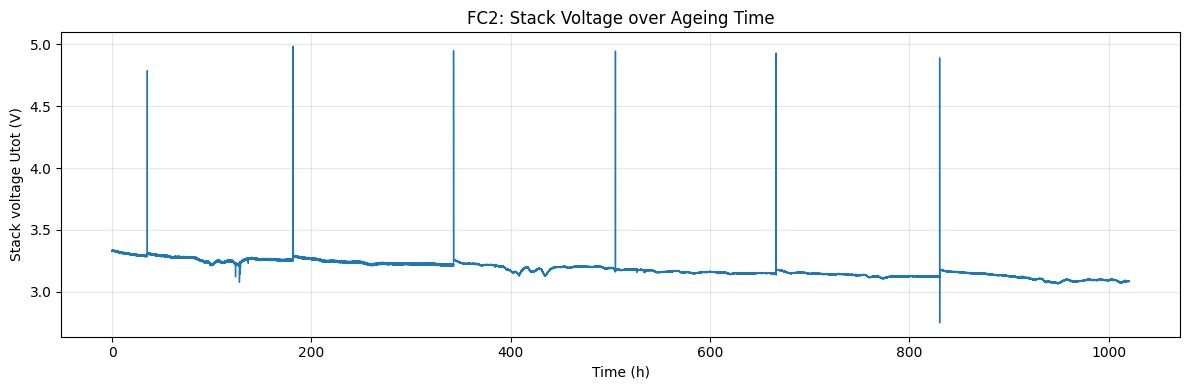

In [10]:
def plot_stack_voltage(df, stack):
    if "Utot_V" not in df.columns:
        print(f"{stack}: Utot_V column missing.")
        return
    
    plt.figure(figsize=(12, 4))
    plt.plot(df["Time_h"], df["Utot_V"], linewidth=1)
    plt.xlabel("Time (h)")
    plt.ylabel("Stack voltage Utot (V)")
    plt.title(f"{stack}: Stack Voltage over Ageing Time")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_figure(f"{stack}_stack_voltage_over_time.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_stack_voltage(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_cell_voltages_over_time.png


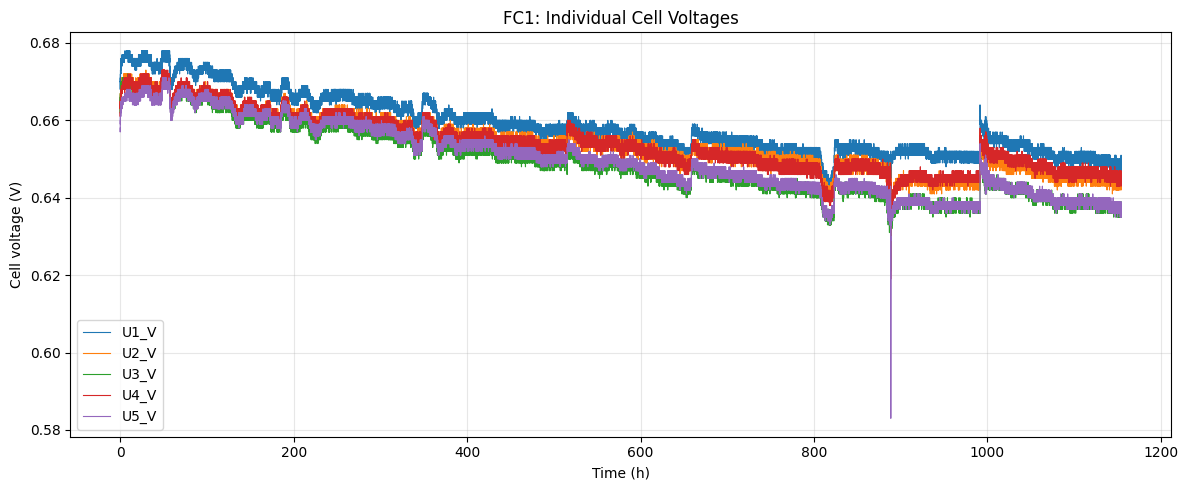

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_cell_voltages_over_time.png


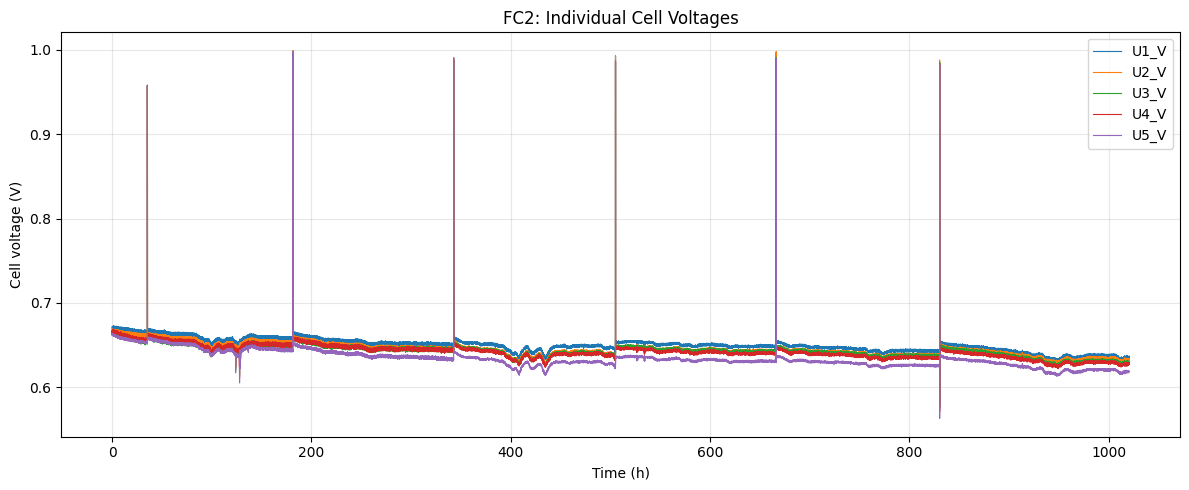

In [11]:
CELL_VOLTAGE_COLS = [
    "U1_V",
    "U2_V",
    "U3_V",
    "U4_V",
    "U5_V",
]


def plot_cell_voltages(df, stack):
    cols = existing_cols(df, CELL_VOLTAGE_COLS)
    
    if len(cols) == 0:
        print(f"{stack}: No cell voltage columns found.")
        return
    
    plt.figure(figsize=(12, 5))
    
    for col in cols:
        plt.plot(df["Time_h"], df[col], linewidth=0.8, label=col)
    
    plt.xlabel("Time (h)")
    plt.ylabel("Cell voltage (V)")
    plt.title(f"{stack}: Individual Cell Voltages")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_cell_voltages_over_time.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_cell_voltages(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_cell_imbalance_over_time.png


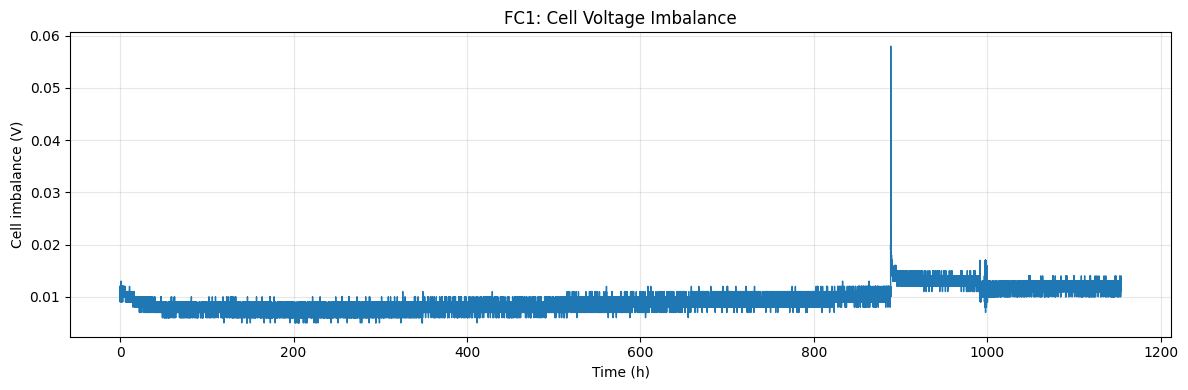

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_cell_imbalance_over_time.png


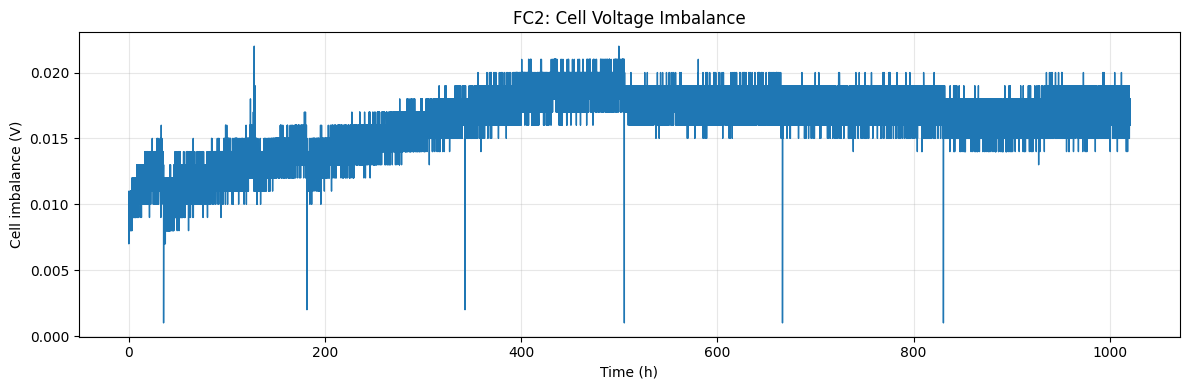

In [12]:
def add_cell_imbalance(df):
    df = df.copy()
    
    cols = existing_cols(df, CELL_VOLTAGE_COLS)
    
    if len(cols) >= 2:
        df["cell_voltage_max_V"] = df[cols].max(axis=1)
        df["cell_voltage_min_V"] = df[cols].min(axis=1)
        df["cell_voltage_mean_V"] = df[cols].mean(axis=1)
        df["cell_voltage_std_V"] = df[cols].std(axis=1)
        df["cell_imbalance_V"] = df["cell_voltage_max_V"] - df["cell_voltage_min_V"]
    else:
        df["cell_imbalance_V"] = np.nan
    
    return df


for stack in list(ageing_data.keys()):
    ageing_data[stack] = add_cell_imbalance(ageing_data[stack])


def plot_cell_imbalance(df, stack):
    if "cell_imbalance_V" not in df.columns:
        print(f"{stack}: cell_imbalance_V missing.")
        return
    
    plt.figure(figsize=(12, 4))
    plt.plot(df["Time_h"], df["cell_imbalance_V"], linewidth=1)
    plt.xlabel("Time (h)")
    plt.ylabel("Cell imbalance (V)")
    plt.title(f"{stack}: Cell Voltage Imbalance")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_figure(f"{stack}_cell_imbalance_over_time.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_cell_imbalance(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_current_and_current_density.png


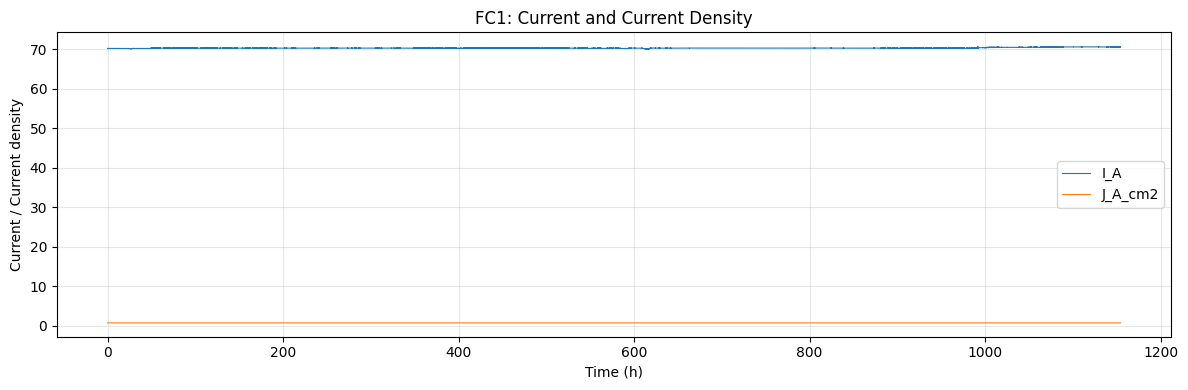

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_current_and_current_density.png


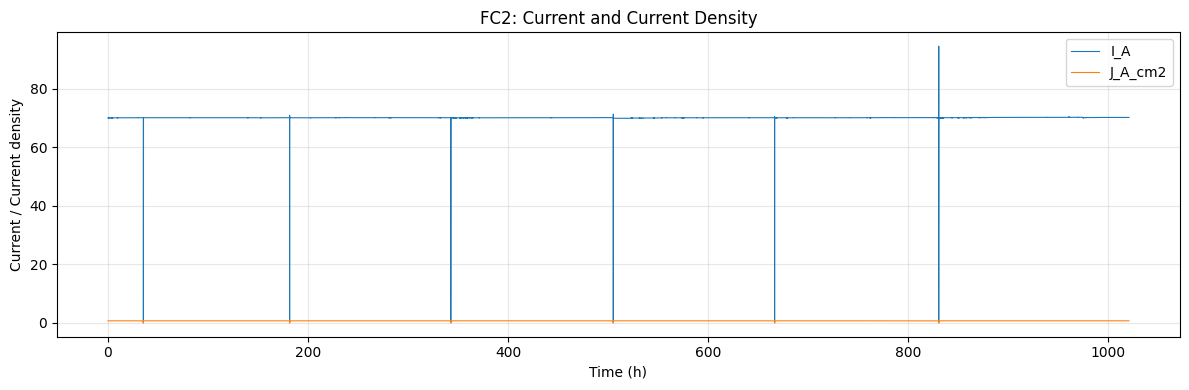

In [13]:
def plot_current_and_j(df, stack):
    cols = existing_cols(df, ["I_A", "J_A_cm2"])
    
    if len(cols) == 0:
        print(f"{stack}: No current columns found.")
        return
    
    plt.figure(figsize=(12, 4))
    
    for col in cols:
        plt.plot(df["Time_h"], df[col], linewidth=0.8, label=col)
    
    plt.xlabel("Time (h)")
    plt.ylabel("Current / Current density")
    plt.title(f"{stack}: Current and Current Density")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_current_and_current_density.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_current_and_j(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_temperatures.png


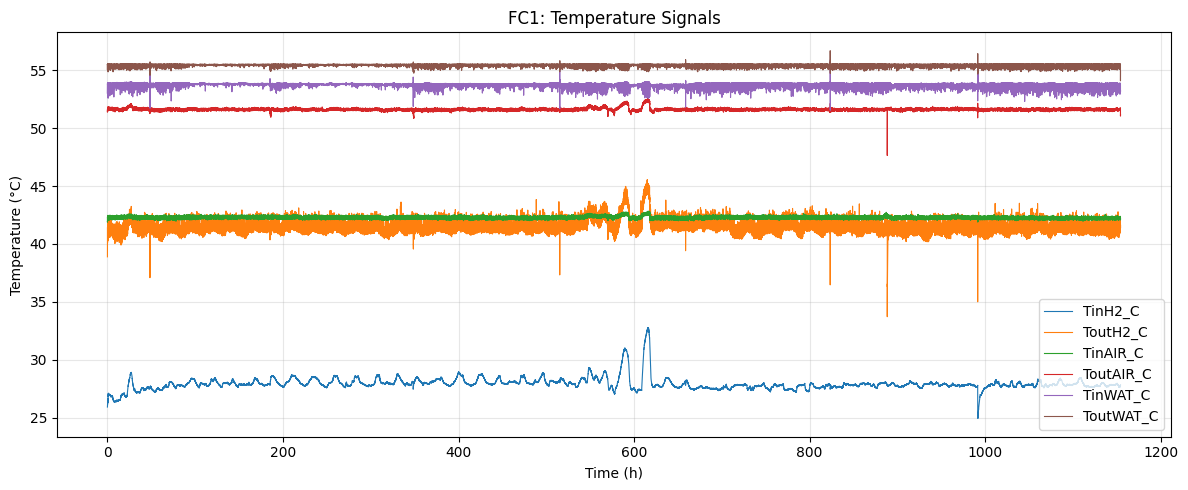

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_temperatures.png


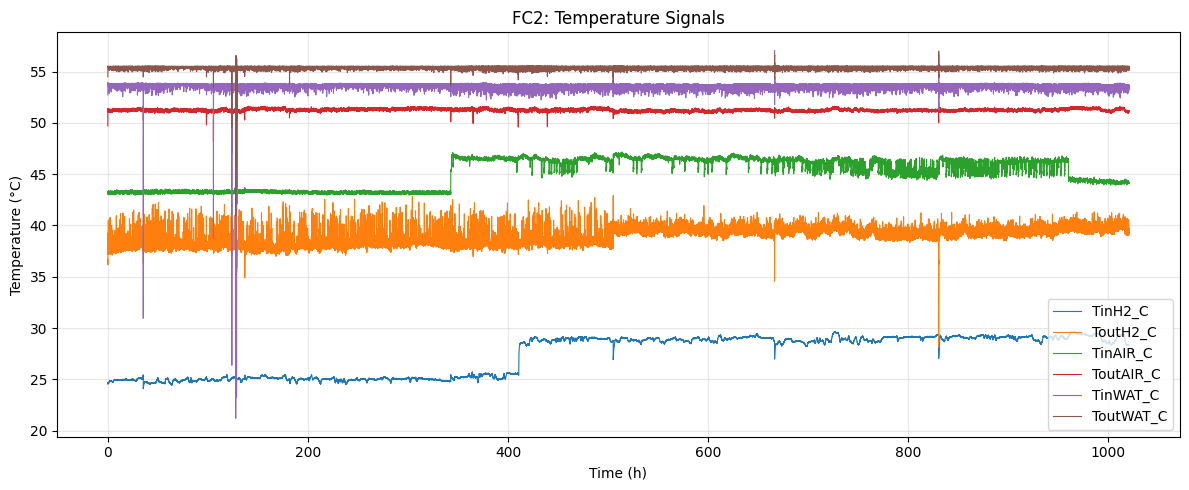

In [14]:
TEMP_COLS = [
    "TinH2_C",
    "ToutH2_C",
    "TinAIR_C",
    "ToutAIR_C",
    "TinWAT_C",
    "ToutWAT_C",
]


def plot_temperatures(df, stack):
    cols = existing_cols(df, TEMP_COLS)
    
    if len(cols) == 0:
        print(f"{stack}: No temperature columns found.")
        return
    
    plt.figure(figsize=(12, 5))
    
    for col in cols:
        plt.plot(df["Time_h"], df[col], linewidth=0.8, label=col)
    
    plt.xlabel("Time (h)")
    plt.ylabel("Temperature (°C)")
    plt.title(f"{stack}: Temperature Signals")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_temperatures.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_temperatures(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_pressures.png


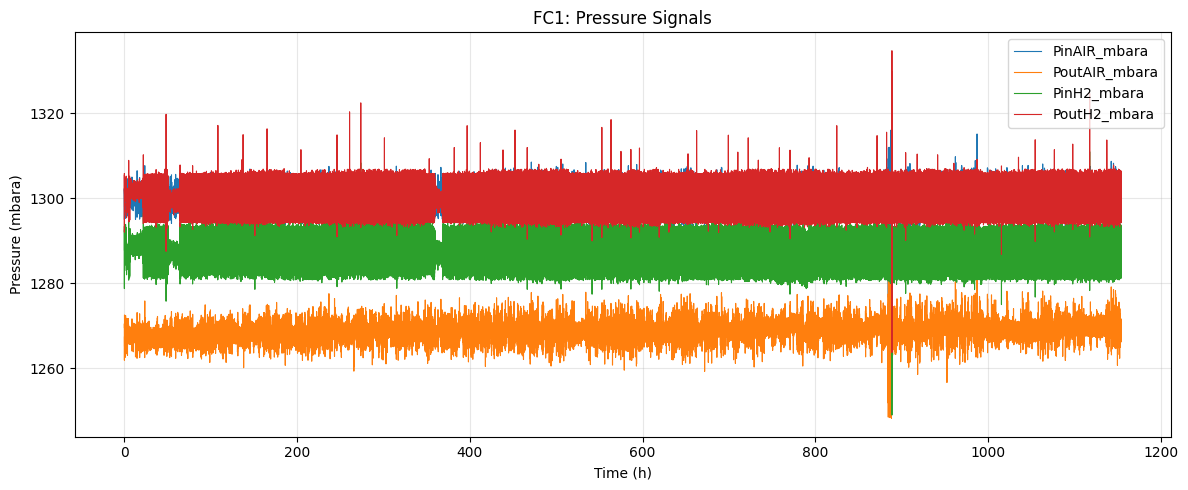

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_pressures.png


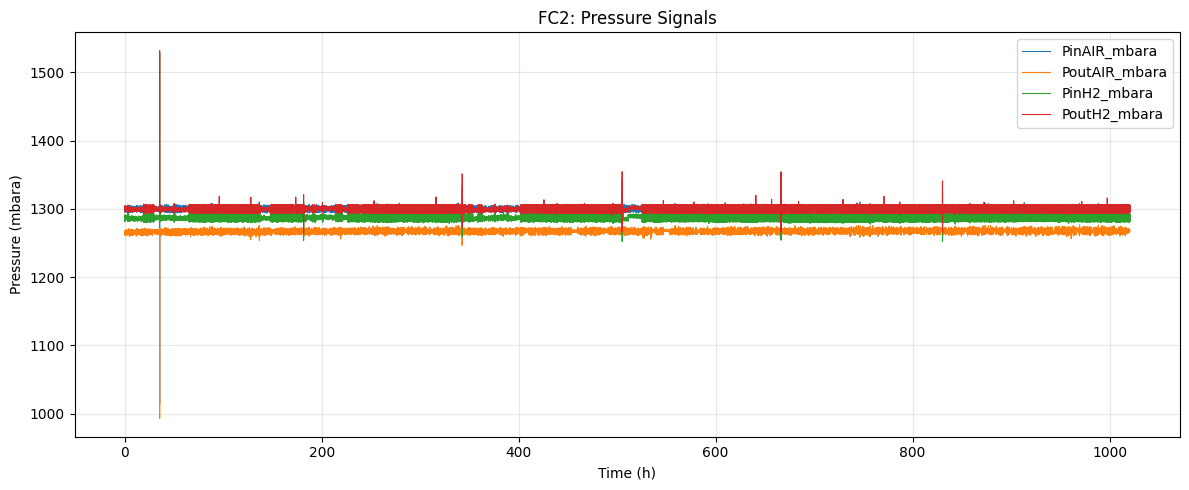

In [15]:
PRESSURE_COLS = [
    "PinAIR_mbara",
    "PoutAIR_mbara",
    "PinH2_mbara",
    "PoutH2_mbara",
]


def plot_pressures(df, stack):
    cols = existing_cols(df, PRESSURE_COLS)
    
    if len(cols) == 0:
        print(f"{stack}: No pressure columns found.")
        return
    
    plt.figure(figsize=(12, 5))
    
    for col in cols:
        plt.plot(df["Time_h"], df[col], linewidth=0.8, label=col)
    
    plt.xlabel("Time (h)")
    plt.ylabel("Pressure (mbara)")
    plt.title(f"{stack}: Pressure Signals")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_pressures.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_pressures(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_flows.png


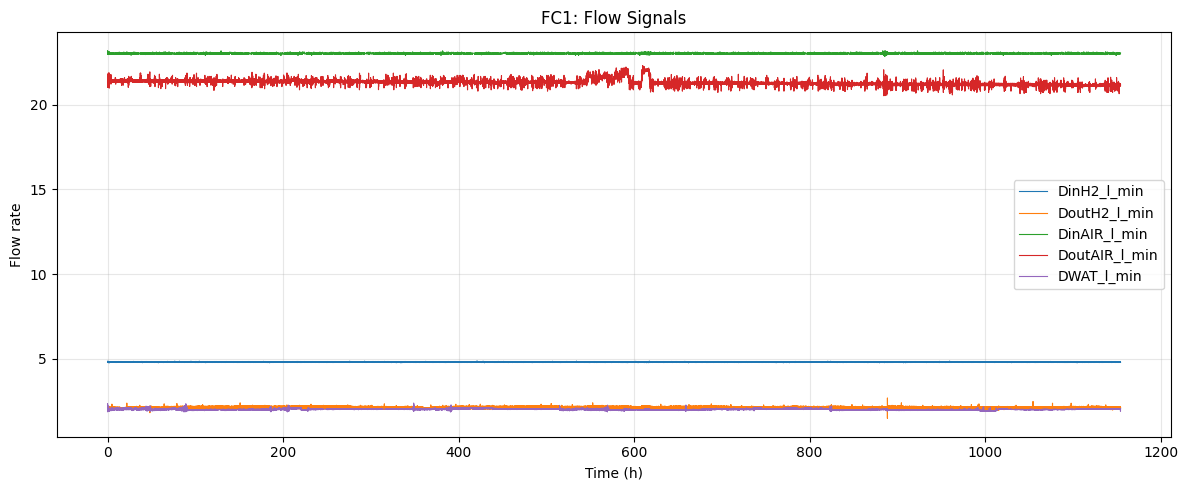

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_humidity.png


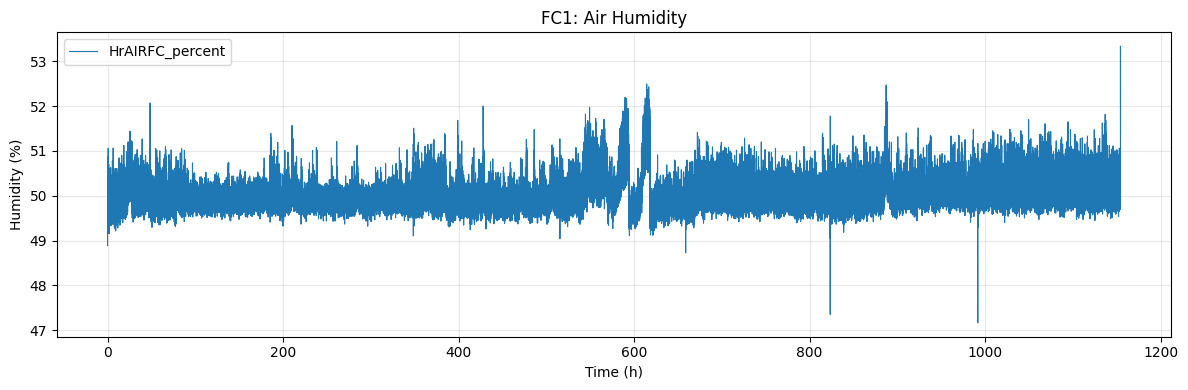

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_flows.png


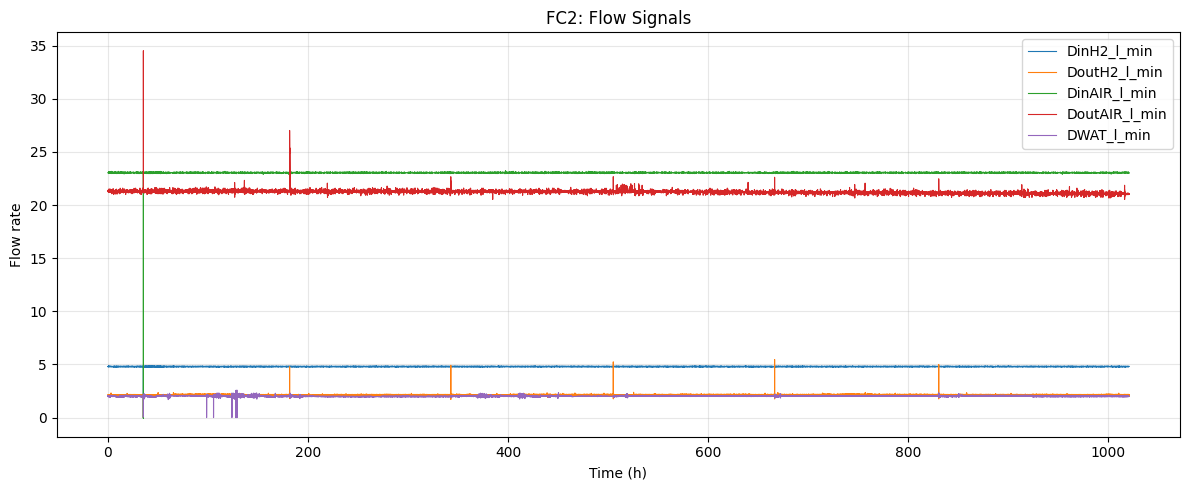

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_humidity.png


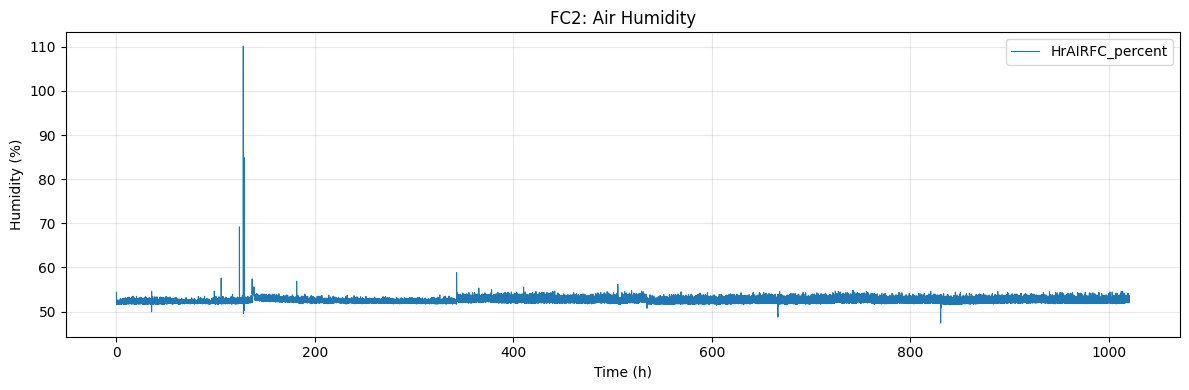

In [16]:
FLOW_COLS = [
    "DinH2_l_min",
    "DoutH2_l_min",
    "DinAIR_l_min",
    "DoutAIR_l_min",
    "DWAT_l_min",
]

HUMIDITY_COLS = [
    "HrAIRFC_percent",
]


def plot_flows(df, stack):
    cols = existing_cols(df, FLOW_COLS)
    
    if len(cols) == 0:
        print(f"{stack}: No flow columns found.")
        return
    
    plt.figure(figsize=(12, 5))
    
    for col in cols:
        plt.plot(df["Time_h"], df[col], linewidth=0.8, label=col)
    
    plt.xlabel("Time (h)")
    plt.ylabel("Flow rate")
    plt.title(f"{stack}: Flow Signals")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_flows.png")
    plt.show()


def plot_humidity(df, stack):
    cols = existing_cols(df, HUMIDITY_COLS)
    
    if len(cols) == 0:
        print(f"{stack}: No humidity columns found.")
        return
    
    plt.figure(figsize=(12, 4))
    
    for col in cols:
        plt.plot(df["Time_h"], df[col], linewidth=0.8, label=col)
    
    plt.xlabel("Time (h)")
    plt.ylabel("Humidity (%)")
    plt.title(f"{stack}: Air Humidity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_humidity.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_flows(df, stack)
    plot_humidity(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_voltage_drop.png


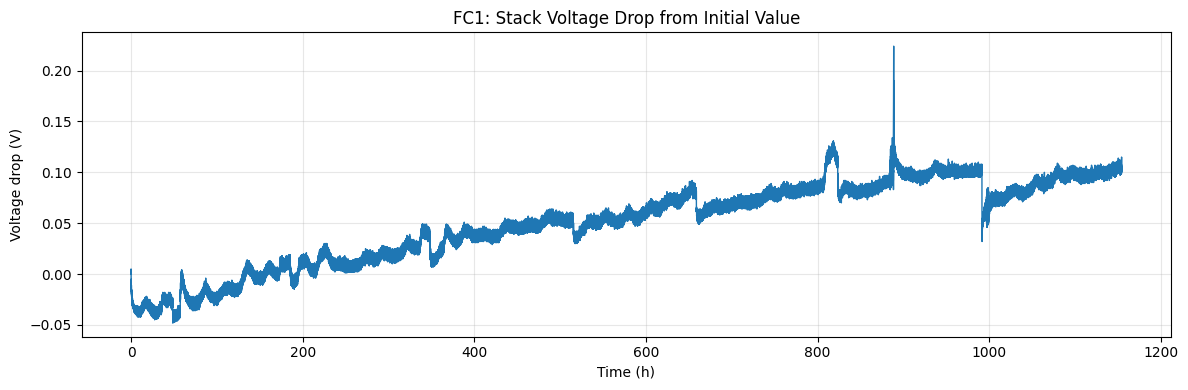

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_voltage_drop.png


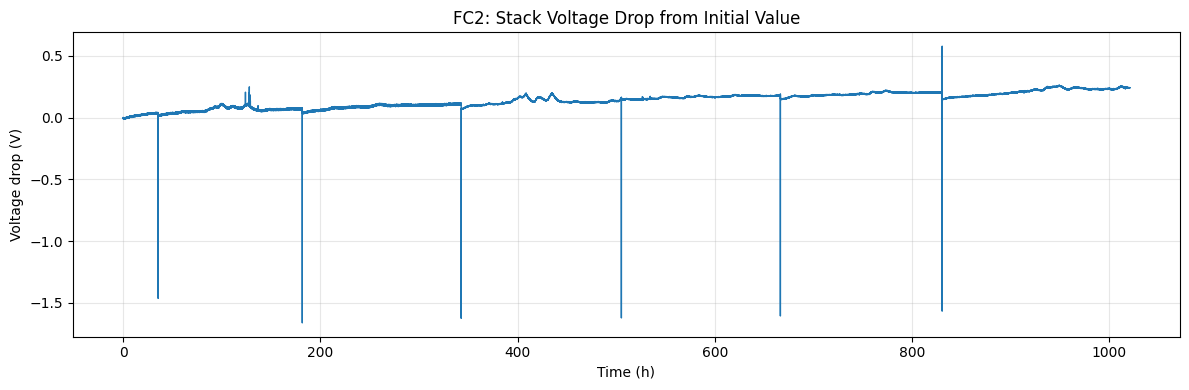

In [17]:
def add_voltage_degradation_features(df):
    df = df.copy()
    
    if "Utot_V" not in df.columns:
        return df
    
    initial_voltage = df["Utot_V"].dropna().iloc[0]
    
    df["Utot_initial_V"] = initial_voltage
    df["voltage_drop_V"] = initial_voltage - df["Utot_V"]
    df["voltage_drop_percent"] = df["voltage_drop_V"] / initial_voltage * 100
    
    return df


for stack in list(ageing_data.keys()):
    ageing_data[stack] = add_voltage_degradation_features(ageing_data[stack])


def plot_voltage_drop(df, stack):
    if "voltage_drop_V" not in df.columns:
        print(f"{stack}: voltage_drop_V missing.")
        return
    
    plt.figure(figsize=(12, 4))
    plt.plot(df["Time_h"], df["voltage_drop_V"], linewidth=1)
    plt.xlabel("Time (h)")
    plt.ylabel("Voltage drop (V)")
    plt.title(f"{stack}: Stack Voltage Drop from Initial Value")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_figure(f"{stack}_voltage_drop.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_voltage_drop(df, stack)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC1_voltage_raw_and_rolling_mean.png


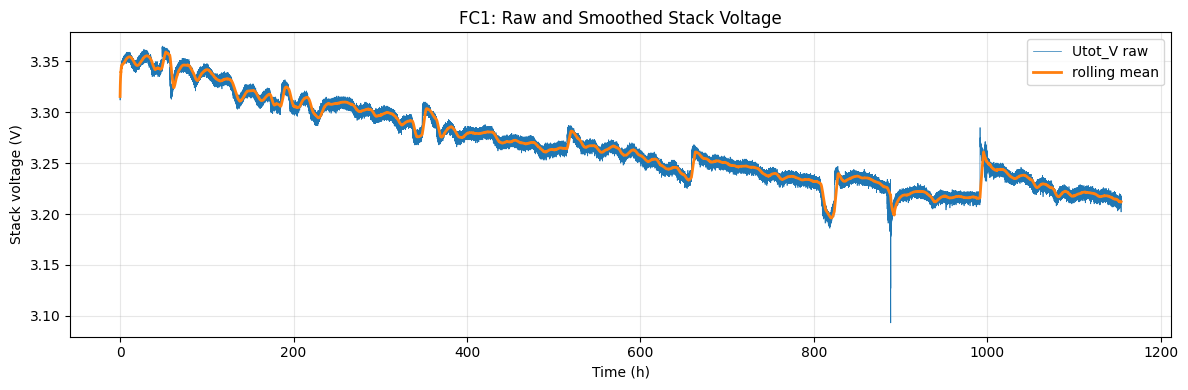

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\figures\stage2\FC2_voltage_raw_and_rolling_mean.png


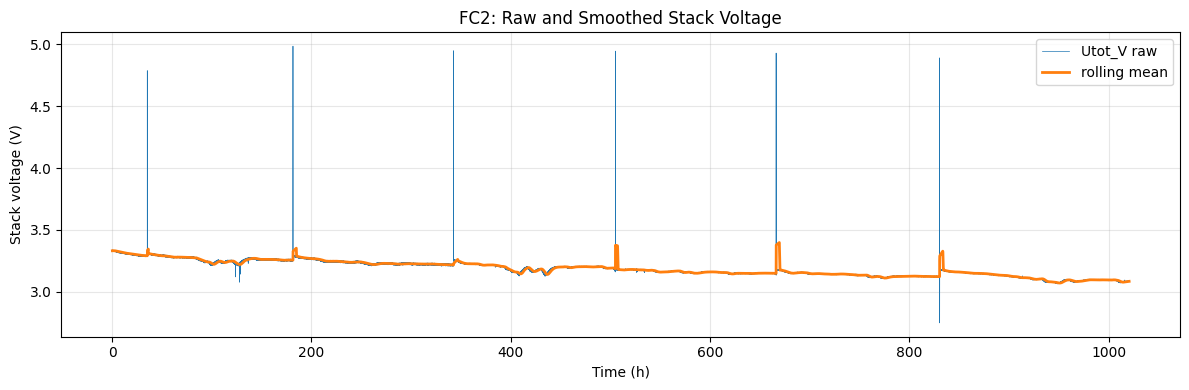

In [18]:
def add_rolling_features(df, window_rows=500):
    df = df.copy()
    
    if "Utot_V" in df.columns:
        df["Utot_rolling_mean_V"] = df["Utot_V"].rolling(
            window=window_rows,
            min_periods=max(5, window_rows // 10)
        ).mean()
        
        df["Utot_rolling_std_V"] = df["Utot_V"].rolling(
            window=window_rows,
            min_periods=max(5, window_rows // 10)
        ).std()
    
    return df


for stack in list(ageing_data.keys()):
    ageing_data[stack] = add_rolling_features(ageing_data[stack], window_rows=500)


def plot_voltage_with_rolling_mean(df, stack):
    if "Utot_rolling_mean_V" not in df.columns:
        print(f"{stack}: rolling mean missing.")
        return
    
    plt.figure(figsize=(12, 4))
    plt.plot(df["Time_h"], df["Utot_V"], linewidth=0.5, label="Utot_V raw")
    plt.plot(df["Time_h"], df["Utot_rolling_mean_V"], linewidth=2, label="rolling mean")
    plt.xlabel("Time (h)")
    plt.ylabel("Stack voltage (V)")
    plt.title(f"{stack}: Raw and Smoothed Stack Voltage")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    
    save_figure(f"{stack}_voltage_raw_and_rolling_mean.png")
    plt.show()


for stack, df in ageing_data.items():
    plot_voltage_with_rolling_mean(df, stack)

In [19]:
enhanced_paths = {}

for stack, df in ageing_data.items():
    out_path = STAGE2_DIR / f"{stack}_ageing_enhanced.csv"
    df.to_csv(out_path, index=False)
    enhanced_paths[stack] = str(out_path)
    print("Saved:", out_path)

Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage2\FC1_ageing_enhanced.csv
Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage2\FC2_ageing_enhanced.csv


In [20]:
def ageing_indicator_summary(df, stack):
    result = {
        "stack": stack,
        "n_rows": len(df),
        "time_start_h": df["Time_h"].min(),
        "time_end_h": df["Time_h"].max(),
        "duration_h": df["Time_h"].max() - df["Time_h"].min(),
    }
    
    if "Utot_V" in df.columns:
        result["Utot_initial_V"] = df["Utot_V"].dropna().iloc[0]
        result["Utot_final_V"] = df["Utot_V"].dropna().iloc[-1]
        result["Utot_min_V"] = df["Utot_V"].min()
        result["Utot_max_V"] = df["Utot_V"].max()
        result["total_voltage_drop_V"] = result["Utot_initial_V"] - result["Utot_final_V"]
        result["total_voltage_drop_percent"] = (
            result["total_voltage_drop_V"] / result["Utot_initial_V"] * 100
        )
    
    if "cell_imbalance_V" in df.columns:
        result["mean_cell_imbalance_V"] = df["cell_imbalance_V"].mean()
        result["max_cell_imbalance_V"] = df["cell_imbalance_V"].max()
    
    if "I_A" in df.columns:
        result["mean_current_A"] = df["I_A"].mean()
        result["std_current_A"] = df["I_A"].std()
    
    if "J_A_cm2" in df.columns:
        result["mean_J_A_cm2"] = df["J_A_cm2"].mean()
        result["std_J_A_cm2"] = df["J_A_cm2"].std()
    
    return result


indicator_rows = []

for stack, df in ageing_data.items():
    indicator_rows.append(ageing_indicator_summary(df, stack))

ageing_indicator_summary_df = pd.DataFrame(indicator_rows)

display(ageing_indicator_summary_df)

indicator_summary_path = STAGE2_TABLE_DIR / "ageing_indicator_summary.csv"
ageing_indicator_summary_df.to_csv(indicator_summary_path, index=False)

print("Saved:", indicator_summary_path)

,stack,n_rows,time_start_h,time_end_h,duration_h,Utot_initial_V,Utot_final_V,Utot_min_V,Utot_max_V,total_voltage_drop_V,total_voltage_drop_percent,mean_cell_imbalance_V,max_cell_imbalance_V,mean_current_A,std_current_A,mean_J_A_cm2,std_J_A_cm2
0,FC1,143862,0.0,1154.213356,1154.213356,3.317,3.211,3.093,3.365,0.106,3.195659,0.009380,0.058,70.256780,0.097947,0.702568,0.000979
1,FC2,127370,0.0,1020.544696,1020.544696,3.325,3.084,2.748,4.986,0.241,7.248120,0.015978,0.022,69.938075,2.874264,0.699381,0.028743


Saved: C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\outputs\tables\stage2\ageing_indicator_summary.csv


In [21]:
stage2_summary = {
    "stage": "Stage 2 - Ageing time-series EDA",
    "stacks_loaded": list(ageing_data.keys()),
    "combined_paths": combined_paths,
    "enhanced_paths": enhanced_paths,
    "quality_summary_path": str(quality_path),
    "indicator_summary_path": str(indicator_summary_path),
    "figure_dir": str(STAGE2_FIGURE_DIR),
}

summary_path = STAGE2_DIR / "stage2_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(stage2_summary, f, indent=4)

print("Saved Stage 2 summary:")
print(summary_path)

Saved Stage 2 summary:
C:\Users\prajoria\Desktop\Codes\ÈIS\pemfc_prognostics\data\processed\stage2\stage2_summary.json
